# Hyperparameter Tuning

Tuning the stochastic programming policy parameters:
- **L**: Planning horizon (tree depth)
- **branching**: Branching factor of the scenario tree
- **n_samples**: Number of samples for uncertainty estimation

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from functools import partial
from itertools import product

import SystemCharacteristics
from Environment import (
    FIXED_DATA, load_data, check_and_sanitize_action,
    apply_overrule, apply_dynamics, load_policy, DUMMY_POLICY
)
from SP_policy_20 import select_action, last_solve_info

DIR = Path(".")

## Configuration

In [2]:
PARAM_GRID = {
    'L': [3, 4, 5, 6, 7, 8, 9, 10],
    'branching': [2, 3, 4],
    'n_samples': [30, 50, 100],
}

DAYS = 2
TOTAL_BUDGET = 7.0

## Evaluation Function

In [3]:
def evaluate_config(L, branching, n_samples, days=DAYS):
    price_data, occ1_data, occ2_data = load_data(
        DIR / "PriceData.csv",
        DIR / "OccupancyRoom1.csv",
        DIR / "OccupancyRoom2.csv"
    )
    dummy_action = load_policy(DUMMY_POLICY, "select_action")

    config_select_action = partial(
        select_action, total_budget=TOTAL_BUDGET, L=L, branching=branching, n_samples=n_samples
    )

    total_cost = 0.0
    timeouts = 0
    suboptimal_solves = 0
    total_solves = 0
    gaps = []

    for day in range(days):
        price = price_data.iloc[day].values
        occupancy1 = occ1_data.iloc[day].values
        occupancy2 = occ2_data.iloc[day].values

        state = {
            "T1": FIXED_DATA["T1"],
            "T2": FIXED_DATA["T2"],
            "H": FIXED_DATA["H"],
            "Occ1": occupancy1[0],
            "Occ2": occupancy2[0],
            "price_t": price[0],
            "price_previous": FIXED_DATA["price_previous"],
            "vent_counter": FIXED_DATA["vent_counter"],
            "low_override_r1": FIXED_DATA["low_override_r1"],
            "low_override_r2": FIXED_DATA["low_override_r2"],
            "current_time": 0
        }

        while state['current_time'] < FIXED_DATA["num_timeslots"]:
            t0 = time.time()
            decision = check_and_sanitize_action(config_select_action, state, dummy_action)
            elapsed = time.time() - t0

            total_solves += 1
            if not last_solve_info['optimal']:
                suboptimal_solves += 1
            gaps.append(last_solve_info['mip_gap'])
            if elapsed > TOTAL_BUDGET:
                timeouts += 1

            decision = apply_overrule(state, decision)
            step_cost = state['price_t'] * (
                decision['HeatPowerRoom1'] + decision['HeatPowerRoom2']
                + decision['VentilationON'] * FIXED_DATA["ventilation_power"]
            )
            total_cost += step_cost
            state = apply_dynamics(state, decision, occupancy1, occupancy2, price)

    avg_daily_cost = total_cost / days
    avg_gap = np.mean(gaps) if gaps else 0.0
    return avg_daily_cost, timeouts, suboptimal_solves, total_solves, avg_gap

## Run Tuning

Set `RUN_TUNING = True` to run from scratch, or `False` to load existing results from CSV.

In [4]:
RUN_TUNING = True
RESULTS_CSV = "tuning_results_20260516_173927.csv"

In [5]:
import subprocess

caffeinate_proc = subprocess.Popen(['caffeinate', '-dims']) if RUN_TUNING else None
if caffeinate_proc is not None:
    print("Mac is caffeinated to the brim - will not sleep til the job is done!")

try:
    if RUN_TUNING:
        np.random.seed(20)

        all_configs = list(product(
            PARAM_GRID['L'],
            PARAM_GRID['branching'],
            PARAM_GRID['n_samples']
        ))

        configs = []
        for L, branching, n_samples in all_configs:
            nodes = (branching**L - 1) // (branching - 1)
            scenarios = branching**(L - 1)
            n_constraints = nodes + scenarios * L
            buffer = 0.2 + 0.0003 * n_constraints
            if buffer < TOTAL_BUDGET:
                configs.append((L, branching, n_samples))

        print(f"Testing {len(configs)} configurations ({len(all_configs) - len(configs)} skipped as too large), {DAYS} days each")
        print(f"Budget per step: {TOTAL_BUDGET}s")
        print("-" * 60)

        results = []
        for i, (L, branching, n_samples) in enumerate(configs, 1):
            print(f"[{i}/{len(configs)}] L={L}, branch={branching}, n_samples={n_samples}...", end=" ")
            t0 = time.time()
            avg_cost, timeouts, suboptimal, total_solves, avg_gap = evaluate_config(L, branching, n_samples)
            runtime = time.time() - t0
            results.append({
                'L': L, 'branching': branching, 'n_samples': n_samples,
                'avg_cost': avg_cost, 'timeouts': timeouts,
                'suboptimal': suboptimal, 'total_solves': total_solves,
                'suboptimal_pct': 100 * suboptimal / total_solves,
                'avg_gap': avg_gap,
                'runtime': runtime
            })
            print(f"cost={avg_cost:.2f}, timeouts={timeouts}, suboptimal={suboptimal}/{total_solves}, avg_gap={avg_gap:.4f}, runtime={runtime:.1f}s")

        df = pd.DataFrame(results)
        from datetime import datetime
        filename = f"tuning_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        df.to_csv(DIR / filename, index=False)
        print(f"\nResults saved to {filename}")
    else:
        df = pd.read_csv(DIR / RESULTS_CSV)
        print(f"Loaded {len(df)} results from {RESULTS_CSV}")
finally:
    if caffeinate_proc is not None:
        caffeinate_proc.terminate()
        caffeinate_proc.wait()
        print("caffeinate released — sleep allowed again.")

df.sort_values('avg_cost').head(10)

Mac is caffeinated to the brim - will not sleep til the job is done!
Testing 54 configurations (18 skipped as too large), 2 days each
Budget per step: 7.0s
------------------------------------------------------------
[1/54] L=3, branch=2, n_samples=30... cost=142.98, timeouts=0, suboptimal=0/20, avg_gap=0.0000, runtime=0.4s
[2/54] L=3, branch=2, n_samples=50... cost=142.65, timeouts=0, suboptimal=0/20, avg_gap=0.0000, runtime=0.3s
[3/54] L=3, branch=2, n_samples=100... cost=143.86, timeouts=0, suboptimal=0/20, avg_gap=0.0000, runtime=0.3s
[4/54] L=3, branch=3, n_samples=30... cost=143.03, timeouts=0, suboptimal=0/20, avg_gap=0.0000, runtime=0.4s
[5/54] L=3, branch=3, n_samples=50... cost=143.00, timeouts=0, suboptimal=0/20, avg_gap=0.0000, runtime=0.5s
[6/54] L=3, branch=3, n_samples=100... cost=142.99, timeouts=0, suboptimal=0/20, avg_gap=0.0000, runtime=0.5s
[7/54] L=3, branch=4, n_samples=30... cost=143.67, timeouts=0, suboptimal=0/20, avg_gap=0.0000, runtime=0.5s
[8/54] L=3, branch

,L,branching,n_samples,avg_cost,timeouts,suboptimal,total_solves,suboptimal_pct,avg_gap,runtime
49,9,2,50,138.470595,0,5,20,25.0,1.316979e-02,43.778526
42,8,2,30,138.473444,0,4,20,20.0,4.815256e-03,43.671337
52,10,2,50,138.477319,0,5,20,25.0,1.877115e-02,43.122826
43,8,2,50,138.480077,0,4,20,20.0,4.322600e-03,44.150052
36,7,2,30,138.480345,0,0,20,0.0,9.569947e-17,19.346638
53,10,2,100,138.490879,0,6,20,30.0,1.703071e-02,45.285309
30,6,3,30,138.508360,0,5,20,25.0,4.980782e-03,59.291580
24,5,4,30,138.540350,0,2,20,10.0,6.592828e-04,36.950924
48,9,2,30,138.786162,0,5,20,25.0,1.027465e-02,44.047288
39,7,3,30,138.789738,0,9,20,45.0,3.167104e-02,62.714776


## Visualization

### Pairwise Heatmaps

For each pair of parameters, we show the minimum average cost across the third parameter. This reveals which parameter combinations yield the best performance.

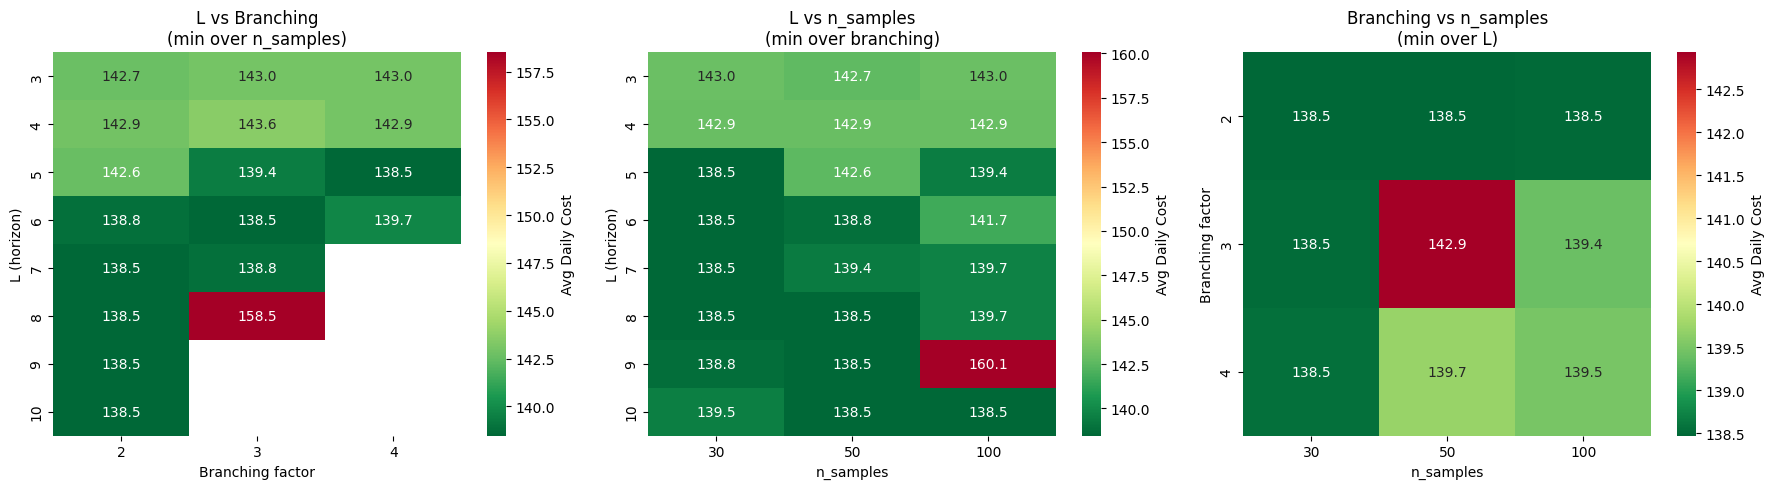

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# L vs branching (min over n_samples)
pivot1 = df.groupby(['L', 'branching'])['avg_cost'].min().reset_index()
pivot1 = pivot1.pivot(index='L', columns='branching', values='avg_cost')
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[0], cbar_kws={'label': 'Avg Daily Cost'})
axes[0].set_title('L vs Branching\n(min over n_samples)')
axes[0].set_ylabel('L (horizon)')
axes[0].set_xlabel('Branching factor')

# L vs n_samples (min over branching)
pivot2 = df.groupby(['L', 'n_samples'])['avg_cost'].min().reset_index()
pivot2 = pivot2.pivot(index='L', columns='n_samples', values='avg_cost')
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[1], cbar_kws={'label': 'Avg Daily Cost'})
axes[1].set_title('L vs n_samples\n(min over branching)')
axes[1].set_ylabel('L (horizon)')
axes[1].set_xlabel('n_samples')

# branching vs n_samples (min over L)
pivot3 = df.groupby(['branching', 'n_samples'])['avg_cost'].min().reset_index()
pivot3 = pivot3.pivot(index='branching', columns='n_samples', values='avg_cost')
sns.heatmap(pivot3, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[2], cbar_kws={'label': 'Avg Daily Cost'})
axes[2].set_title('Branching vs n_samples\n(min over L)')
axes[2].set_ylabel('Branching factor')
axes[2].set_xlabel('n_samples')

plt.tight_layout()
plt.show()

### Cost vs Runtime Trade-off

Configurations that are both cheap and fast are ideal (bottom-left corner).

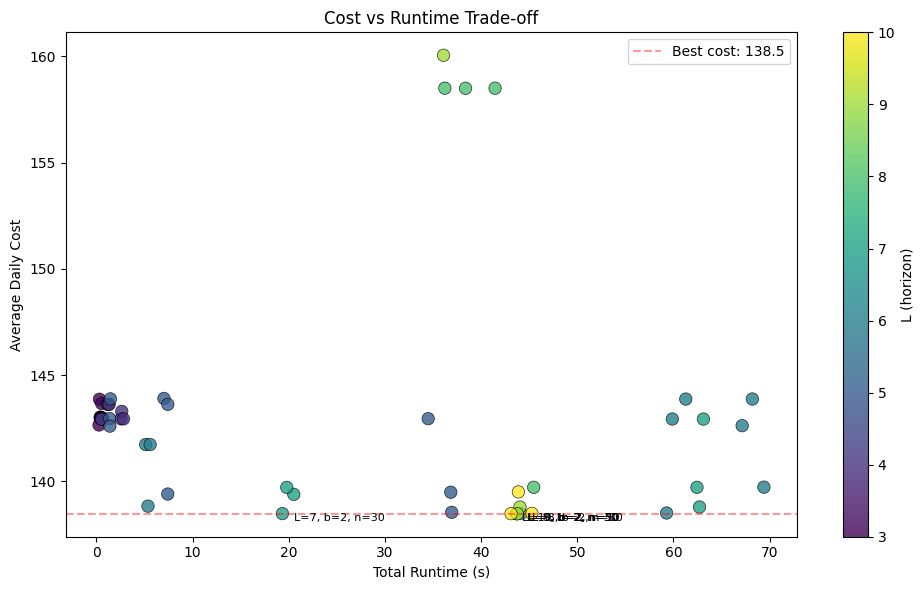

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['runtime'], df['avg_cost'],
    c=df['L'], cmap='viridis', s=80, edgecolors='k', linewidths=0.5, alpha=0.8
)

for _, row in df.nsmallest(5, 'avg_cost').iterrows():
    ax.annotate(
        f"L={int(row['L'])}, b={int(row['branching'])}, n={int(row['n_samples'])}",
        (row['runtime'], row['avg_cost']),
        textcoords="offset points", xytext=(8, -5), fontsize=8
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('L (horizon)')
ax.set_xlabel('Total Runtime (s)')
ax.set_ylabel('Average Daily Cost')
ax.set_title('Cost vs Runtime Trade-off')
ax.axhline(df['avg_cost'].min(), color='red', linestyle='--', alpha=0.4, label=f"Best cost: {df['avg_cost'].min():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

### Effect of Each Parameter (marginal)

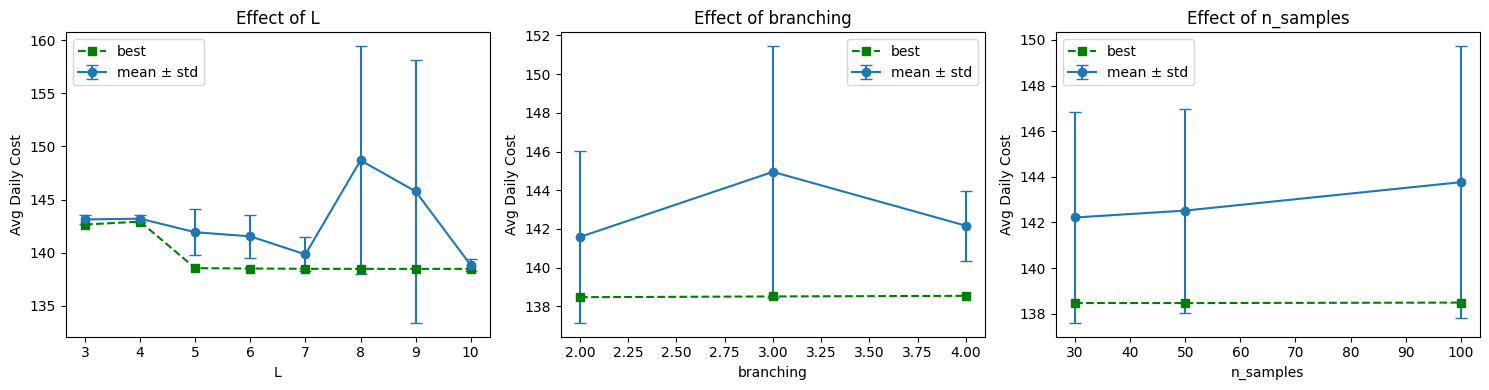

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ['L', 'branching', 'n_samples']):
    grouped = df.groupby(param)['avg_cost'].agg(['mean', 'min', 'std']).reset_index()
    ax.errorbar(grouped[param], grouped['mean'], yerr=grouped['std'], fmt='o-', capsize=4, label='mean \u00b1 std')
    ax.plot(grouped[param], grouped['min'], 's--', color='green', label='best')
    ax.set_xlabel(param)
    ax.set_ylabel('Avg Daily Cost')
    ax.set_title(f'Effect of {param}')
    ax.legend()

plt.tight_layout()
plt.show()

### Timeouts & Suboptimal Solves

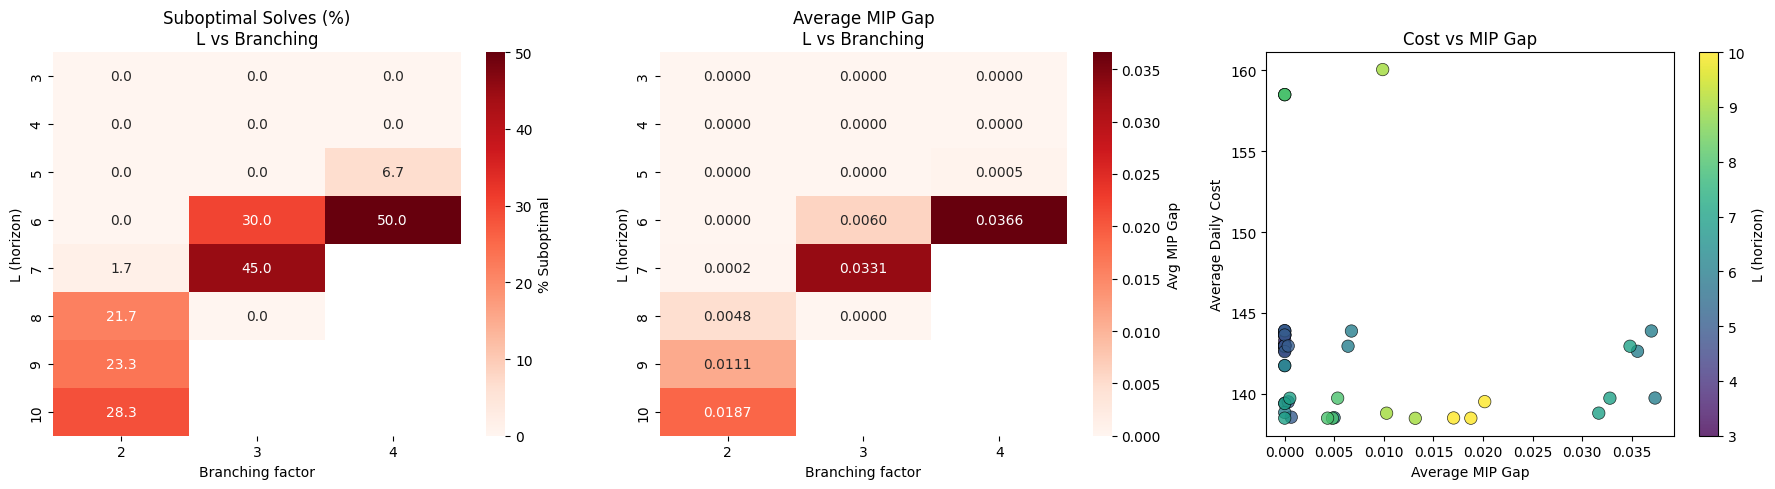


1 configurations had timeouts:

 L  branching  n_samples   avg_cost  timeouts  suboptimal_pct  avg_gap   runtime
 9          2        100 160.056326         1            20.0 0.009879 36.098278


In [9]:
has_gap = 'avg_gap' in df.columns
has_subopt = 'suboptimal_pct' in df.columns

if has_gap or has_subopt:
    ncols = (1 if has_subopt else 0) + (2 if has_gap else 0)
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
    if ncols == 1:
        axes = [axes]
    idx = 0

    if has_subopt:
        pivot_sub = df.groupby(['L', 'branching'])['suboptimal_pct'].mean().reset_index()
        pivot_sub = pivot_sub.pivot(index='L', columns='branching', values='suboptimal_pct')
        sns.heatmap(pivot_sub, annot=True, fmt='.1f', cmap='Reds', ax=axes[idx], cbar_kws={'label': '% Suboptimal'})
        axes[idx].set_title('Suboptimal Solves (%)\nL vs Branching')
        axes[idx].set_ylabel('L (horizon)')
        axes[idx].set_xlabel('Branching factor')
        idx += 1

    if has_gap:
        # Gap heatmap: L vs branching
        pivot_gap = df.groupby(['L', 'branching'])['avg_gap'].mean().reset_index()
        pivot_gap = pivot_gap.pivot(index='L', columns='branching', values='avg_gap')
        sns.heatmap(pivot_gap, annot=True, fmt='.4f', cmap='Reds', ax=axes[idx], cbar_kws={'label': 'Avg MIP Gap'})
        axes[idx].set_title('Average MIP Gap\nL vs Branching')
        axes[idx].set_ylabel('L (horizon)')
        axes[idx].set_xlabel('Branching factor')
        idx += 1

        # Scatter: avg_gap vs avg_cost
        axes[idx].scatter(df['avg_gap'], df['avg_cost'], c=df['L'], cmap='viridis',
                        s=80, edgecolors='k', linewidths=0.5, alpha=0.8)
        cbar = plt.colorbar(axes[idx].collections[0], ax=axes[idx])
        cbar.set_label('L (horizon)')
        axes[idx].set_xlabel('Average MIP Gap')
        axes[idx].set_ylabel('Average Daily Cost')
        axes[idx].set_title('Cost vs MIP Gap')

    plt.tight_layout()
    plt.show()
else:
    print("No 'avg_gap' or 'suboptimal_pct' columns — re-run tuning with RUN_TUNING=True to collect these metrics.")

# Timeout summary
timeout_configs = df[df['timeouts'] > 0].sort_values('timeouts', ascending=False)
if len(timeout_configs) > 0:
    print(f"\n{len(timeout_configs)} configurations had timeouts:\n")
    cols = ['L', 'branching', 'n_samples', 'avg_cost', 'timeouts']
    if has_subopt:
        cols.append('suboptimal_pct')
    if has_gap:
        cols.append('avg_gap')
    cols.append('runtime')
    print(timeout_configs[cols].to_string(index=False))
else:
    print("No configurations had timeouts.")